# HydroSeason: DEA Acquisition — Fitzroy/Kimberley AOI

**What this shows:** the building blocks behind DEA WOfS acquisition —
loading an AOI, querying DEA STAC, summarising to monthly extent, and
detecting hydrological years — against a **real AOI**
(`data/fitzroy_kimberley_aoi.geojson`, Fitzroy River near Derby, Kimberley
WA).

**Requirements:** `pip install hydroseason[stac]` (pulls in
`pystac-client`, `odc-stac`, `rioxarray`, `geopandas`, `dask`).

**Network:** yes — queries the live DEA STAC catalog.

**Runtime:** a few minutes, depending on connection speed.

> For most use cases, prefer the one-call orchestrator instead of these
> individual steps:
> ```python
> result = run_hydroseason(
>     output_dir="output/fitzroy",
>     aoi="fitzroy_kimberley_aoi.geojson",
>     aoi_name="Fitzroy River",
>     start_date="2015-01-01",
>     end_date="2025-12-01",
> )
> ```
> See [01_quickstart.ipynb](01_quickstart.ipynb) and the
> [Usage Guide](https://tayerthiaggo.github.io/hydroseason/guide/#3-fetch-dea-wofs-for-an-aoi)
> for the orchestrator version of this workflow.

This notebook instead walks through the lower-level building blocks it's
made of — useful when you need more control than the orchestrator exposes:

1. Load AOI polygon.
2. Query + load monthly WOfS composites from DEA STAC (`load_wofs_from_stac`), clipped to the AOI.
3. Summarise monthly water extent (`monthly_water_extent`).
4. Detect hydrological years (`detect_hydrological_years`).
5. Label months Wet/Dry (`label_hydrological_months`).
6. Plot + generate interactive HTML report (`generate_html_report`).

In [1]:
from __future__ import annotations

import os

# A system-wide PROJ_LIB pointing at an incompatible proj.db (e.g. from a
# PostGIS install) breaks pyproj/rasterio CRS lookups; force pyproj's own
# bundled database instead.
os.environ.pop('PROJ_LIB', None)
os.environ.pop('PROJ_DATA', None)

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

from hydroseason import (
    detect_hydrological_years,
    label_hydrological_months,
    load_aoi,
    load_wofs_from_stac,
    monthly_water_extent,
    suggest_hydro_year_config,
    generate_html_report,
)

print('Imports successful!')

Imports successful!


## 1. Configuration

Single input block: AOI path, STAC endpoint/collection, and the date range for the analysis.

In [2]:
AOI_PATH = Path('../data/fitzroy_kimberley_aoi.geojson')

STAC_URL = 'https://explorer.dea.ga.gov.au/stac'
COLLECTION = 'ga_ls_wo_3'  # Landsat WOfS, per-scene water classification

START_DATE = '2015-01-01'
END_DATE = '2025-12-31'

OUTPUT_CRS = 3577  # GDA94 / Australian Albers, matches WOFS pipeline contract

REPORT_PATH = Path('hydroseason_fitzroy_kimberley_report.html')

## 2. Load AOI

Reads and validates the AOI polygon (non-empty, valid geometry).

AOI features: 1
AOI CRS: EPSG:4326
AOI bounds (lon/lat): [123.90787628 -18.16809454 124.21704519 -18.04020627]


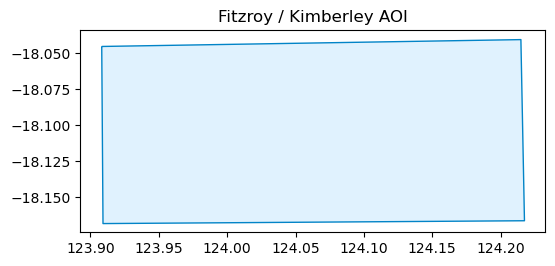

In [3]:
aoi_gdf = load_aoi(AOI_PATH)
print(f'AOI features: {len(aoi_gdf)}')
print(f'AOI CRS: {aoi_gdf.crs}')
print(f'AOI bounds (lon/lat): {aoi_gdf.total_bounds}')
aoi_gdf.plot(edgecolor='#0284c7', facecolor='#e0f2fe', figsize=(6, 6))
plt.title('Fitzroy / Kimberley AOI')
plt.show()

## 3. Pull WOfS from DEA STAC

Queries the STAC catalog for the AOI bbox and date range, groups observations by month, composites them (majority vote), and clips every month to the AOI polygon. This is a lazy, dask-backed cube — nothing is computed yet.

In [4]:
water_mask = load_wofs_from_stac(
    STAC_URL,
    COLLECTION,
    AOI_PATH,
    START_DATE,
    END_DATE,
    crs=OUTPUT_CRS,
)

print(f'Loaded cube: {dict(water_mask.sizes)}')
print(f'Months: {water_mask.sizes["time"]}')
print(f'Inserted (gap-filled) months: {water_mask.attrs.get("n_inserted_timesteps", 0)}')

c:\Users\00101125\AppData\Local\anaconda3\envs\project56_1\Lib\site-packages\cupy\_environment.py:215: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(
D:\RLH\5.6\repos\hydroseason\hydroseason\io.py:228: UserWarning: Converting to Period representation will drop timezone information.
  groups.setdefault(date.to_period("M").to_timestamp(), []).append(item)


Loaded cube: {'time': 132, 'y': 539, 'x': 1117}
Months: 132
Inserted (gap-filled) months: 0


## 4. Summarise Monthly Water Extent

Computes the dask graph once and returns `extent_pct` / `invalid_pct` per month.

In [5]:
extent = monthly_water_extent(water_mask)
print(f'Extent series shape: {extent.shape}')
print(f'Max invalid_pct: {extent["invalid_pct"].max():.1f}%')
print(f'Months with invalid_pct > 50%: {(extent["invalid_pct"] > 50).sum()}')
extent.head(12)

c:\Users\00101125\AppData\Local\anaconda3\envs\project56_1\Lib\site-packages\rasterio\warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Extent series shape: (132, 6)
Max invalid_pct: 92.7%
Months with invalid_pct > 50%: 1


,n_water,n_aoi,n_valid,n_invalid,extent_pct,invalid_pct
2015-01-01,282,499979,36649,463330,0.769462,92.669892
2015-02-01,8369,499979,489204,10775,1.710738,2.155091
2015-03-01,6294,499979,486840,13139,1.292827,2.627910
2015-04-01,4615,499979,489257,10722,0.943267,2.144490
2015-05-01,3959,499979,489235,10744,0.809223,2.148890
2015-06-01,3481,499979,489215,10764,0.711548,2.152890
2015-07-01,3011,499979,489219,10760,0.615471,2.152090
2015-08-01,2728,499979,489248,10731,0.557590,2.146290
2015-09-01,2332,499979,489246,10733,0.476652,2.146690
2015-10-01,1791,499979,489243,10736,0.366076,2.147290


## 5. Detect Hydrological Years

Same detection API as the mock-data walkthrough, applied to the real remote-sensing series. `suggest_hydro_year_config` derives the wet/dry search windows from this AOI's own monthly climatology instead of hardcoding a region assumption — inspect the proposal before trusting it (bimodal or noisy climatologies can still mislead it). Adjust `max_invalid_pct` / `missing_month_policy` after inspecting cloud/gap coverage above.

In [6]:
config = suggest_hydro_year_config(extent)
print(f'Suggested config: {config}')

# 2015-01 is the only month above 50% invalid coverage in this AOI (start of
# the Landsat WOfS record has partial scene overlap here); 95% comfortably
# clears it without silently accepting a systematically bad month elsewhere.
hydro_years = detect_hydrological_years(
    extent,
    config=config,
    missing_month_policy='ignore',
    max_invalid_pct=95.0,
)

print(f'Detected {len(hydro_years)} hydrological years:')
hydro_years

Detected 11 hydrological years:


,hy_year,hy_start,hy_end,peak_month,peak_extent_pct,mid_dry_month,mid_extent_pct,end_dry_month,end_extent_pct,amplitude_pct,n_months_cycle,confidence,boundary_source
0,2015,2015-01-01,2015-12-01,2015-02-01,1.710738,2015-07-01,0.615471,2015-12-01,0.070603,1.640136,12,low,annual_window_low_amplitude
1,2016,2016-01-01,2016-11-01,2016-02-01,1.037308,2016-07-01,0.252243,2016-11-01,0.040470,0.996838,11,low,annual_window_low_amplitude
2,2017,2016-12-01,2017-11-01,2017-02-01,50.849357,2017-07-01,1.309904,2017-11-01,0.798981,50.050375,12,high,annual_window
3,2018,2017-12-01,2018-12-01,2018-02-01,6.932218,2018-07-01,1.060259,2018-12-01,0.645259,6.286960,13,high,annual_window
4,2019,2019-01-01,2019-12-01,2019-03-01,1.128708,2019-07-01,0.618334,2019-12-01,0.370045,0.758663,12,low,annual_window_low_amplitude
5,2020,2020-01-01,2020-11-01,2020-03-01,10.813485,2020-07-01,0.636753,2020-11-01,0.060555,10.752930,11,high,annual_window
6,2021,2020-12-01,2021-12-01,2021-03-01,34.863511,2021-07-01,1.221751,2021-12-01,0.540206,34.323305,13,high,annual_window
7,2022,2022-01-01,2022-11-01,2022-02-01,7.392260,2022-07-01,0.785132,2022-11-01,0.568419,6.823841,11,high,annual_window
8,2023,2022-12-01,2023-12-01,2023-01-01,20.237842,2023-07-01,1.403677,2023-12-01,0.427176,19.810666,13,high,annual_window
9,2024,2024-01-01,2024-10-01,2024-03-01,8.593304,2024-06-01,0.580932,2024-10-01,0.134083,8.459222,10,high,annual_window


## 6. Label Months + Visualise

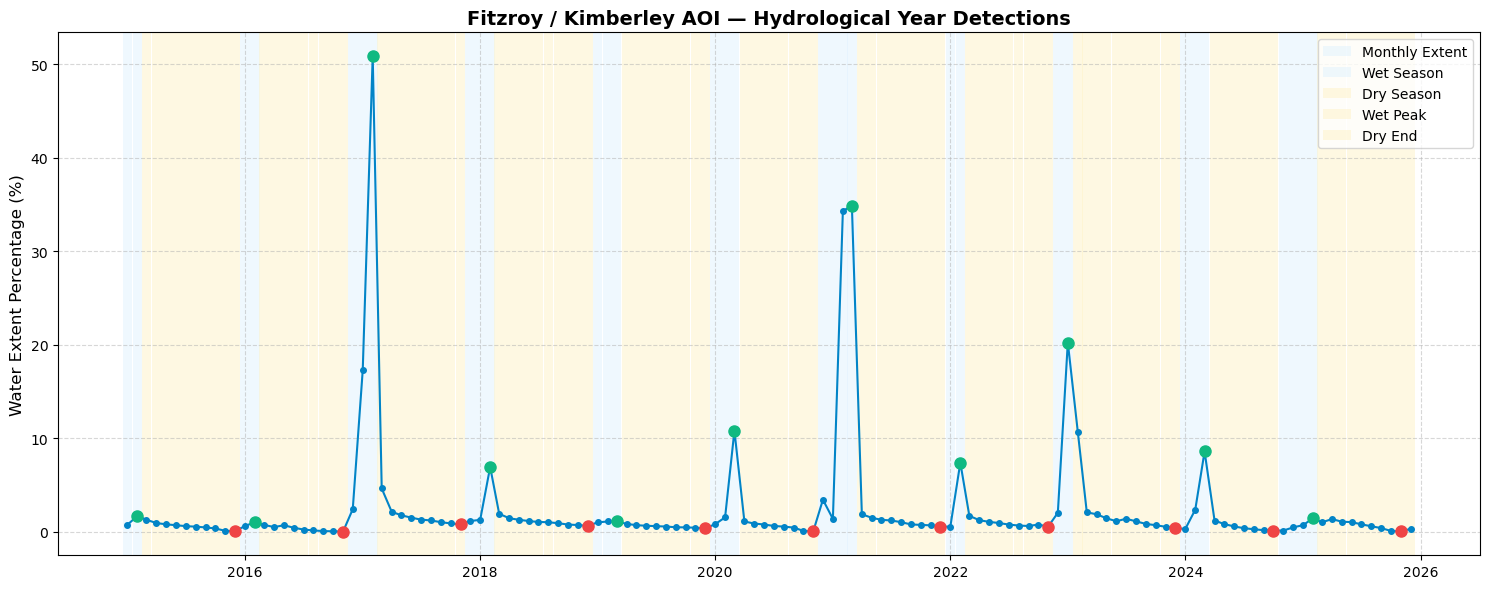

In [7]:
labels = label_hydrological_months(extent.index, hydro_years)

plt.figure(figsize=(15, 6))
for ts, row in labels.iterrows():
    color = '#e0f2fe' if row['season'] == 'Wet' else '#fef3c7'
    plt.axvspan(ts - pd.Timedelta(days=15), ts + pd.Timedelta(days=15), color=color, alpha=0.5, linewidth=0)

plt.plot(extent.index, extent['extent_pct'], color='#0284c7', marker='o', markersize=4, label='Monthly Extent (%)')
for _, row in hydro_years.iterrows():
    plt.plot(pd.Timestamp(row['peak_month']), row['peak_extent_pct'], marker='o', color='#10b981', markersize=8, zorder=5)
    plt.plot(pd.Timestamp(row['end_dry_month']), row['end_extent_pct'], marker='o', color='#ef4444', markersize=8, zorder=5)

plt.title('Fitzroy / Kimberley AOI — Hydrological Year Detections', fontsize=14, fontweight='bold')
plt.ylabel('Water Extent Percentage (%)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(['Monthly Extent', 'Wet Season', 'Dry Season', 'Wet Peak', 'Dry End'], loc='upper right')
plt.tight_layout()
plt.show()

## 7. Generate HTML Report

In [ ]:
generate_html_report(
    extent=extent,
    hydro_years=hydro_years,
    output_path=REPORT_PATH,
    title='HydroSeason — Fitzroy / Kimberley AOI (DEA STAC WOfS)',
)

print(f'HTML report written to: {REPORT_PATH.resolve()}')